# Exploration of YOLO-World: High-Speed Zero-Shot Object Detection

Click the `Open in Colab` button to run this notebook directly in Google Colab.

<br>

YOLO-World was developed to bridge the gap between high-accuracy zero-shot models and real-time performance. While many state-of-the-art models rely on slower Transformer architectures, YOLO-World utilizes the highly efficient CNN-based YOLO framework.

According to the paper YOLO-World reached between 35.4 AP with 52.0 FPS for the large version and 26.2 AP with 74.1 FPS for the small version. While the V100 is a powerful GPU, achieving such high FPS on any device is impressive.

![visualization results of referring object detection](https://storage.googleapis.com/com-roboflow-marketing/supervision/cookbooks/yolo-world-visualization-results-of-referring-object-detection.png)

## Getting Started

First, we should verify that a GPU is available. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/Users/alisultanomariv/Documents/Zero-Shot Object Detection with YOLO-World


## Installing Dependencies

To get started, we need two main libraries: `inference`, for executing zero-shot object detection using YOLO-World, and `supervision`, for post-processing and visualizing the detected objects.

In [3]:
!pip install --upgrade pip
!pip install setuptools wheel
!pip install "numpy>=1.26"
!pip install -q "inference[yolo-world]" supervision


In [4]:
!pip install -q supervision==0.19.0rc3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trackers 2.3.0 requires supervision>=0.26.1, but you have supervision 0.19.0rc3 which is incompatible.
inference-models 0.27.2 requires supervision>=0.26.0, but you have supervision 0.19.0rc3 which is incompatible.
inference 1.2.7 requires supervision>=0.26, but you have supervision 0.19.0rc3 which is incompatible.
inference 1.2.7 requires supervision>=0.27.0, but you have supervision 0.19.0rc3 which is incompatible.


## Imports

In [5]:
import cv2
import supervision as sv

from tqdm import tqdm
from inference.models.yolo_world.yolo_world import YOLOWorld

## Fetching Sample Data

In [13]:
# Wrap {HOME} in quotes to handle the spaces in your folder name
!wget -P "{HOME}" -q https://media.roboflow.com/notebooks/examples/dog.jpeg
!wget -P "{HOME}" -q https://media.roboflow.com/supervision/cookbooks/yellow-filling.mp4


In [7]:
SOURCE_IMAGE_PATH = f"{HOME}/dog.jpeg"
SOURCE_VIDEO_PATH = f"{HOME}/yellow-filling.mp4"

**NOTE:** If you want to run the cookbook using your own file as input, simply upload video to Google Colab and replace `SOURCE_IMAGE_PATH` and `SOURCE_VIDEO_PATH` with the path to your file.

## Initializing the Model

The Inference package provides the YOLO-World model in three versions: `S`, `M`, and `L`. You can load them by defining model_id as `yolo_world/s`, `yolo_world/m`, and `yolo_world/l`, respectively. The `ROBOFLOW_API_KEY` is not required to utilize this model.







In [8]:
yolo_detector = YOLOWorld(model_id="yolo_world/l")

Creating inference sessions


/Users/alisultanomariv/Documents/Zero-Shot Object Detection with YOLO-World/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/Users/alisultanomariv/Documents/Zero-Shot Object Detection with YOLO-World/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'OpenVINOExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
2026-05-05 18:19:42.067243 [W:onnxruntime:, coreml_execution_provider.cc:112 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 17 number of nodes in the graph: 985 number of nodes supported by CoreML: 43
2026-

CLIP model loaded in 5.09 seconds


As a zero-shot model, YOLO-World can detect objects without any specific fine-tuning. You only need to define a prompt as a list of classes (things) you are searching for.

In [11]:
target_labels = ["person", "backpack", "dog", "eye", "nose", "ear", "tongue"]
yolo_detector.set_classes(target_labels)

We perform detection on our sample image. Then, we convert the result into a [`sv.Detections`](https://supervision.roboflow.com/latest/detection/core/) object, which will be useful in the later parts of the cookbook.

In [14]:
image = cv2.imread(SOURCE_IMAGE_PATH)
results = yolo_detector.infer(image)
detection_results = sv.Detections.from_inference(results)

The results we've obtained can be easily visualized with [`sv.BoundingBoxAnnotator`](https://supervision.roboflow.com/latest/detection/annotators/#supervision.annotators.core.BoundingBoxAnnotator) and [`sv.LabelAnnotator`](https://supervision.roboflow.com/latest/detection/annotators/#supervision.annotators.core.LabelAnnotator). We can adjust parameters such as line thickness, text scale, line and text color allowing for a highly tailored visualization experience.

In [15]:
BOUNDING_BOX_ANNOTATOR = sv.BoundingBoxAnnotator(thickness=2)
LABEL_ANNOTATOR = sv.LabelAnnotator(text_thickness=2, text_scale=1, text_color=sv.Color.BLACK)

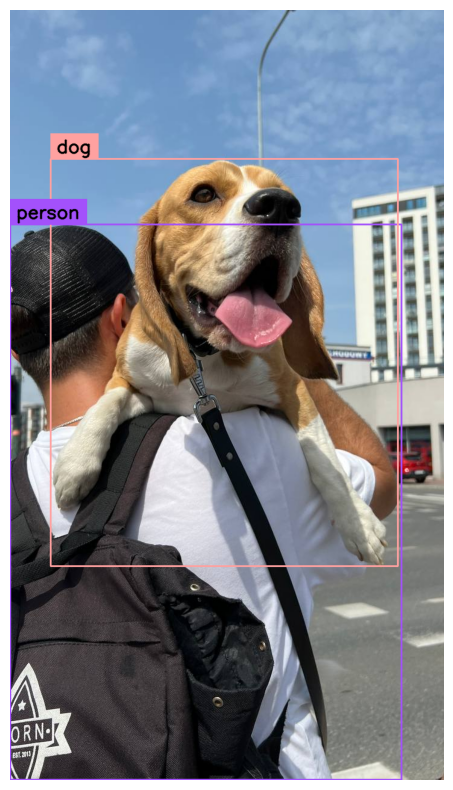

In [16]:
annotated_image = image.copy()
annotated_image = BOUNDING_BOX_ANNOTATOR.annotate(annotated_image, detection_results)
annotated_image = LABEL_ANNOTATOR.annotate(annotated_image, detection_results)
sv.plot_image(annotated_image, (10, 10))

## Adjusting Confidence Level

Note that many classes from our prompt were not detected. This is because the default confidence threshold in Inference is set to `0.5`. Let's try significantly lowering this value. We've observed that the confidence returned by YOLO-World is significantly lower when querying for classes outside the [COCO](https://universe.roboflow.com/microsoft/coco) dataset.

In [17]:
image = cv2.imread(SOURCE_IMAGE_PATH)
results = yolo_detector.infer(image, confidence=0.003)
detection_results = sv.Detections.from_inference(results)

By default, `sv.LabelAnnotator` displays only the names of objects. To also view the confidence levels associated with each detection, we must define custom `labels` and pass them to `sv.LabelAnnotator`.

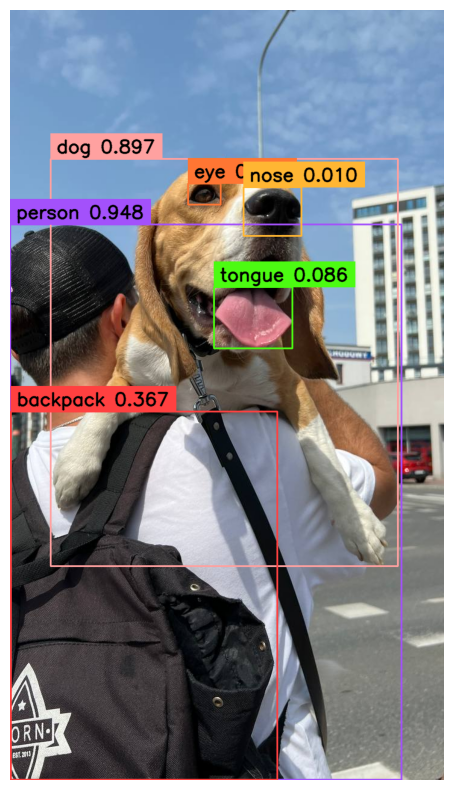

In [19]:
labels = [
    f"{target_labels[class_id]} {confidence:0.3f}"  # <-- Change 'classes' to 'target_labels'
    for class_id, confidence
    in zip(detection_results.class_id, detection_results.confidence)
]


annotated_image = image.copy()
annotated_image = BOUNDING_BOX_ANNOTATOR.annotate(annotated_image, detection_results)
annotated_image = LABEL_ANNOTATOR.annotate(annotated_image, detection_results, labels=labels)
sv.plot_image(annotated_image, (10, 10))

## Using Non-Max Suppression (NMS) to Eliminate Double Detections

To eliminate duplicates, we will use [Non-Max Suppression (NMS)](https://blog.roboflow.com/how-to-code-non-maximum-suppression-nms-in-plain-numpy). NMS evaluates the extent to which detections overlap using the Intersection over Union metric and, upon exceeding a defined threshold, treats them as duplicates. Duplicates are then discarded, starting with those of the lowest confidence. The value should be within the range `[0, 1]`. The smaller the value, the more restrictive the NMS.







In [20]:
image = cv2.imread(SOURCE_IMAGE_PATH)
results = yolo_detector.infer(image, confidence=0.003)
detection_results = sv.Detections.from_inference(results).with_nms(threshold=0.1)

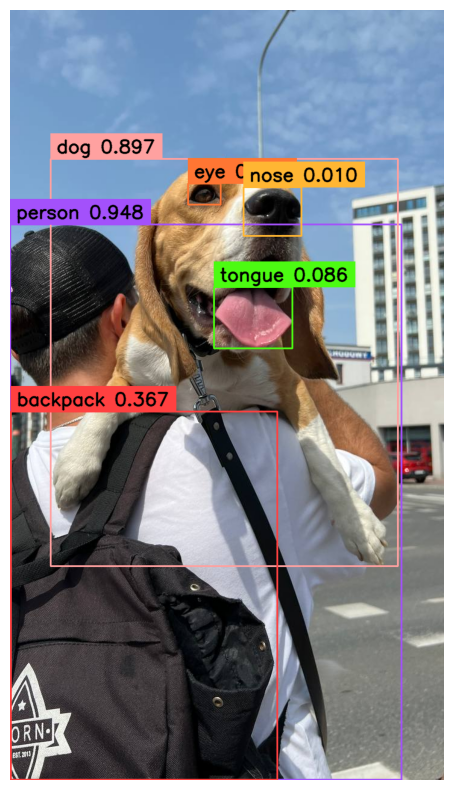

In [22]:
labels = [
    f"{target_labels[class_id]} {confidence:0.3f}"
    for class_id, confidence
    in zip(detection_results.class_id, detection_results.confidence)
]

annotated_image = image.copy()
annotated_image = BOUNDING_BOX_ANNOTATOR.annotate(annotated_image, detection_results)
annotated_image = LABEL_ANNOTATOR.annotate(annotated_image, detection_results, labels=labels)
sv.plot_image(annotated_image, (10, 10))

## Video Processing

The [`get_video_frames_generator`](https://supervision.roboflow.com/latest/utils/video/#supervision.utils.video.get_video_frames_generator) enables us to easily iterate over video frames. Let's create a video generator for our sample input file and display its first frame on the screen.

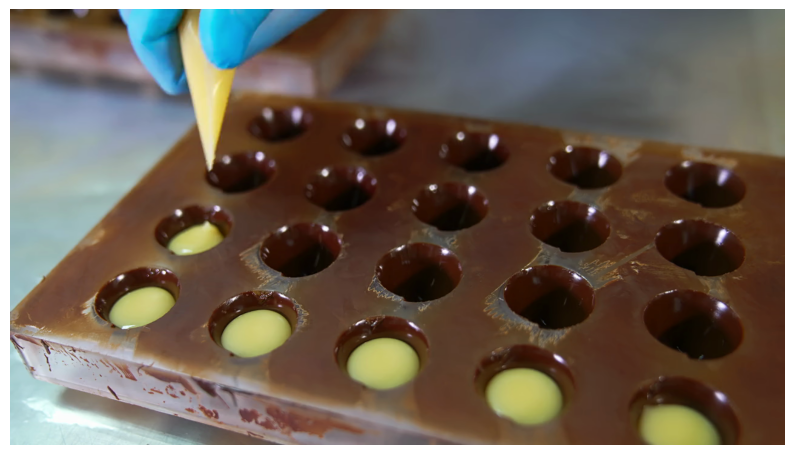

In [23]:
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(generator)

sv.plot_image(frame, (10, 10))

Let's update our list of classes. This time we are looking for `yellow filling`. The rest of the code performing detection, filtering and visualization remains unchanged.

In [25]:
target_labels = ["yellow filling"]
yolo_detector.set_classes(target_labels)

In [26]:
results = yolo_detector.infer(frame, confidence=0.002)
detection_results = sv.Detections.from_inference(results).with_nms(threshold=0.1)

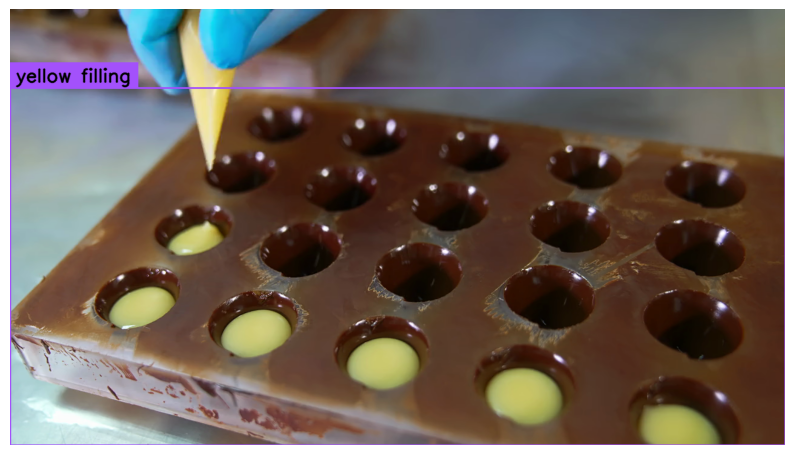

In [27]:
annotated_image = frame.copy()
annotated_image = BOUNDING_BOX_ANNOTATOR.annotate(annotated_image, detection_results)
annotated_image = LABEL_ANNOTATOR.annotate(annotated_image, detection_results)
sv.plot_image(annotated_image, (10, 10))

## Filtering Detectuions by Area

Our prompt allowed us to locate all filled holes, but we also accidentally marked the entire high-level element. To address this issue, we'll filter detections based on their relative area in relation to the entire video frame. If a detection occupies more than 10% of the frame's total area, it will be discarded.

We can use [`VideoInfo.from_video_path`](https://supervision.roboflow.com/develop/utils/video/#supervision.utils.video.VideoInfo) to learn basic information about our video, such as duration, resolution, or FPS.

In [28]:
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_info

VideoInfo(width=1280, height=720, fps=25, total_frames=442)

Knowing the frame's resolution allows us to easily calculate its total area, expressed in pixels.

In [29]:
width, height = video_info.resolution_wh
frame_area = width * height
frame_area

921600

On the other hand, by using [`sv.Detections.area`](https://supervision.roboflow.com/develop/detection/core/#supervision.detection.core.Detections.area) property, we can learn the area of each individual bounding box.

In [30]:
results = yolo_detector.infer(frame, confidence=0.002)
detection_results = sv.Detections.from_inference(results).with_nms(threshold=0.1)
detection_results.area

array([ 7.5428e+05])

Now, we can combine these two pieces of information to construct a filtering condition for detections with an area greater than 10% of the entire frame.

In [31]:
(detection_results.area / frame_area) < 0.10

array([False])

In [33]:
# Change 'detections.area' to 'detection_results.area'
detection_results = detection_results[(detection_results.area / frame_area) < 0.10]

annotated_image = frame.copy()
annotated_image = BOUNDING_BOX_ANNOTATOR.annotate(annotated_image, detection_results)


## Final Result

Now we can process the full video and observe the model's performance. Now in truth we can appreciate the speed of YOLO-World.

In [34]:
TARGET_VIDEO_PATH = f"{HOME}/yellow-filling-output.mp4"

In [36]:
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

width, height = video_info.resolution_wh
frame_area = width * height
frame_area

with sv.VideoSink(target_path=TARGET_VIDEO_PATH, video_info=video_info) as sink:
    for frame in tqdm(frame_generator, total=video_info.total_frames):
        results = yolo_detector.infer(frame, confidence=0.002)
        detection_results = sv.Detections.from_inference(results).with_nms(threshold=0.1)
        detection_results = detection_results[(detection_results.area / frame_area) < 0.10]


        annotated_frame = frame.copy()
        annotated_frame = BOUNDING_BOX_ANNOTATOR.annotate(annotated_frame, detection_results)
        annotated_frame = LABEL_ANNOTATOR.annotate(annotated_frame, detection_results)
        sink.write_frame(annotated_frame)

100%|██████████| 442/442 [02:11<00:00,  3.37it/s]


 Keep in mind that the video preview below works only in the web version of the cookbooks and not in Google Colab.

<video controls>
    <source
        src="https://storage.googleapis.com/com-roboflow-marketing/supervision/cookbooks/yellow-filling-output-1280x720.mp4"
        type="video/mp4"
    >
</video>

## 🛠️ Installation & Setup

To get started with **YOLO-World**, we need to install a few key libraries. These handle everything from model execution to drawing the results on your images.

### 1. Install Core Libraries
*   **`inference`**: The engine that actually runs the YOLO-World model.
*   **`supervision`**: A toolkit used to process detections and draw bounding boxes/labels.
*   **`ultralytics`**: Required for loading local model weights and advanced features.

### 2. Check for Hardware Acceleration
Since you are on a Mac, this notebook will attempt to use your **Apple Silicon Neural Engine (MPS)** or **Metal GPU** automatically for real-time performance.


In [58]:
# Download the actual YOLO-World-L weights file to your project folder
!wget -P "{HOME}" -q https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8l-world.pt

# Rename it to something easier to remember
!mv "{HOME}/yolov8l-world.pt" "{HOME}/my_yolo_world_model.pt"

print("Done! You should now see 'my_yolo_world_model.pt' in your file list.")


Done! You should now see 'my_yolo_world_model.pt' in your file list.


## 💾 Loading the Local Model Weights

This step is the "offline" way to run the model. Instead of relying on a hidden cache or a cloud download, we are loading the exact model file we just downloaded to our project folder.

### What is happening here?
1. **`from ultralytics import YOLOWorld`**: We switch to the Ultralytics library, which is excellent at handling local `.pt` files.
2. **`model_path`**: We point the code to the specific file on your Mac (`my_yolo_world_model.pt`).
3. **`YOLOWorld(model_path)`**: This loads the "Large" YOLO-World brain into your computer's memory.
4. **`set_classes(target_labels)`**: We tell the model exactly what objects to look for. This "grounds" the model so it knows that when it sees a certain shape, it should label it as a "backpack" or "dog."


In [61]:
from ultralytics import YOLOWorld

# Now this file will actually exist!
model_path = f"{HOME}/my_yolo_world_model.pt"
yolo_detector = YOLOWorld(model_path)

# Set your target classes
target_labels = ["person", "backpack", "dog", "eye", "nose", "ear", "tongue"]
yolo_detector.set_classes(target_labels)


100%|███████████████████████████████████████| 338M/338M [00:33<00:00, 10.7MiB/s]
